# Machine learning: Reconnaissance de sorts (magiques)

## 1. Introduction

### a) Rappels

Ce notebook fait suite au TP Perceptron dans lequel nous avions construit un petit réseau de neurones - appelé perceptron - pour effectuer de la reconnaissance de caractères.


<img src="https://github.com/PlantecJY/python-mic/raw/master/principe.png" alt="Drawing" width="300" align="center"/>


Nous avions suivi les étapes ci-dessous :
* Structuration des données pour l’apprentissage (un dictionnaire de chiffres écrits représentés par des tableaux 5*6, comme dans l'exemple ci-dessous

```
nb9b = [[1,1,1,1,1],
        [1,0,0,0,1],
        [1,0,0,0,1],
        [1,1,1,1,1],
        [0,0,0,0,1],
        [1,1,1,1,1]]
```
* Création du réseau de neurones : une couche d'entrée de dimension 300 et une couche de sortie de dimension 10 ; l'information passée à chaque neurone de sortie était simplement la combinaison linéaire des neurones reliés à cette sortie pondérée par le poids de chaque neurone ;
* Test du fonctionnement du réseau de neurones ;
* Apprentissage, c'est-dire-optimisation du poids de chaque neurone ;
* Utilisation du réseau de neurones pour une faire une prédiction : on fournit un chiffre sous forme de tableau et on demande au réseau de prédire ce chiffre.

### b) Objectif de ce TP

Dans ce TP, l'objectif est de comprendre toute la chaîne d'apprentissage en Machine Learning à travers le domaine de la reconnaissance de gestes, et plus particulièrement de sorts (magiques). Nous allons donc passer par les étapes suivantes:
  1) Acquisition des données brutes et construction d'un dataset
  2) Split données d'entraînement/ données de test
  3) Pré-traitement des données (génération de features)
  4) Entraînement d'un modèle léger (réseau de neurones)
  5) Test du modèle
  6) Déploiement embarqué sur une carte 

## 2. Construction d'un dataset

Pour cette première étape, nous allons télécharger une base de données contenant déjà un certains nombre de gestes par label (qui sont au nombre de 3):
* 100 gestes du sort "Wingardium Leviosa"
* 100 gestes du sort "Stupefy"
* 100 gestes du sort "Expelliarmus"

Les gestes sont enregistrés, carte à la main, pendant une durée de 5 secondes, il est important de respecter ce temps d'acquisition pour l'enregistrement de nouvelles données.

L'objectif ici est de construire un tableau sur Python contenant les données que l'on pourra ensuite traîter pour entraîner/tester le modèle futur.


### a) Importation des bibliothèques nécessaires

In [1]:
!pip install pyserial
import zipfile
import os
import glob
import json
import pandas as pd
import os


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


### b) Upload d'un dataset et rangement des données dans un tableau

Remarque: ici, les données sont dites "brutes", elles ne sont pas encore traitées pour entraîner et tester le modèle, on a ici les acquisitions temporelles de chaque enregistrements de gestes, ce qui donne beaucoup plus de lignes sur le tableau que de fichiers réels.

In [2]:
import pandas as pd

data = pd.read_csv("dataset_sorts_xiao.csv")

colonnes_attendues = [
    "AxX", "AxY", "AxZ",
    "GxX", "GxY", "GxZ",
    "source_file", "label", "origine",
]

colonnes_manquantes = set(colonnes_attendues) - set(data.columns)
if colonnes_manquantes:
    raise ValueError(f"Colonnes manquantes : {colonnes_manquantes}")

print("Taille du dataset :", data.shape)
display(
    data.groupby("label")["source_file"]
    .nunique()
    .rename("nombre_de_gestes")
    .to_frame()
)
data.head()


Taille du dataset : (75157, 9)


,nombre_de_gestes
label,
Expelliarmus,100
Stupefy,100
Wingardium Leviosa,100


,AxX,AxY,AxZ,GxX,GxY,GxZ,source_file,label,origine
0,-0.417240,-0.122488,0.926712,0.07,-2.31,-1.47,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao
1,-0.410408,-0.142496,0.925736,-0.63,-1.12,-1.12,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao
2,-0.417728,-0.147376,0.917928,0.21,-0.77,-0.07,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao
3,-0.410896,-0.139080,0.936472,-0.98,-1.33,0.63,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao
4,-0.404552,-0.135664,0.916952,1.75,0.98,1.61,Expelliarmus_001_20260717_125857_459000,Expelliarmus,xiao


### c) Questions

1) Quelle est la fréquence d'enregistrement des données?
2) Que contient le fichier data_sort?
3) Quelle est la taille du dataset? Pourquoi est-il plus grand que le nombre d'enregistrements de base (300 au total)? Aidez vous de l'affichage des premières lignes du tableau.
4) Pourquoi est-il important de vérifier la qualité des données avant de commencer l'entraînement d'un modèle ?

## 3. Acquisition de nouvelles données

Dans cette section, il est possible d'enregistrer de nouvelles données pour compléter le dataset déjà existant ou ajouter un nouveau label et enregistrer ses données à l'aide de la carte Seeed Xiao NRF52840 sense.
Cela se fait à l'aide d'un menu interactif qui vous permettra d'avoir plusieurs options d'acquisition de données.

### a) Présentation de la carte Seeed Xiao NRF52840 sense

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/Seeed-Studio-XIAO-nRF52840-Sense.jpg" width="300">

La carte Seeed Xiao NRF52840 sense est équipée d'un IMU (Inertial Measurement Unit), qui renvoie les données d'un gyroscope (sur 3 axes) et d'un accéléromètre (sur 3 axes), cela nous permettra d'analyser les gestes réalisées.

Les étapes à suivre pour faire l'acquisition de nouvelles données sont:
* Brancher la carte sur un port USB
* Ajuster le numéro du port avec le "COMX", X le numéro du port.
* Lancer le menu d'acquisition

### a) Importation des bibliothèques nécessaires

In [3]:
import serial
import time
import pandas as pd
from datetime import datetime

### b) Les fonctions nécessaires au menu d'acquisition

In [4]:
# ============================================================
# 3 - Acquisition de nouvelles données avec Seeed XIAO nRF52840
# ============================================================

PORT = "COM10"          # À modifier selon ton ordinateur
BAUDRATE = 115200
DUREE_ACQUISITION = 5  # durée d'une acquisition en secondes

# On reprend les colonnes capteurs du dataset déjà chargé
colonnes_capteurs = [
    "AxX",
    "AxY",
    "AxZ",
    "GxX",
    "GxY",
    "GxZ"
]


#Fonction permettant de choisir le label sur lequel sera enregistré la nouvelle donnée
def choisir_label():
    labels = sorted(data["label"].unique())

    print("\n1 - Créer un nouveau label")
    print("2 - Utiliser un label existant")

    choix = input("Choix : ")

    if choix == "1":
        label = input("Nom du nouveau label : ").strip()
        return label

    elif choix == "2":
        print("\nLabels existants :")
        for i, label in enumerate(labels):
            print(f"{i + 1} - {label}")

        choix_label = int(input("Choisir un label : ")) - 1

        if 0 <= choix_label < len(labels):
            return labels[choix_label]
        else:
            print("Choix invalide.")
            return None

    else:
        print("Choix invalide.")
        return None


#Fonction permettant de lire le capteur de la Seeed Xiao
def lire_fenetre_xiao(label):
    global data

    donnees = []

    print(f"\nPrépare le geste pour le label : {label}")
    input("Appuie sur Entrée pour lancer l'acquisition...")

    ser = serial.Serial(PORT, BAUDRATE, timeout=1)
    time.sleep(3)  # laisse le temps à la XIAO de redémarrer

    ser.reset_input_buffer()
    ser.reset_output_buffer()

    # Envoie la commande de départ
    ser.write(b"S")
    ser.flush()

    print("Acquisition en cours...")

    debut = time.time()

    while True:
        ligne = ser.readline().decode("utf-8", errors="ignore").strip()

        if ligne == "":
            continue

        if ligne == "FIN":
            break

        try:
            valeurs = [float(x) for x in ligne.split(",")]

            if len(valeurs) == len(colonnes_capteurs):
                donnees.append(valeurs)
            else:
                print("Ligne ignorée, mauvais nombre de valeurs :", ligne)

        except:
            print("Ligne ignorée :", ligne)

    ser.close()

    if len(donnees) == 0:
        print("Aucune donnée reçue.")
        return None

    df_new = pd.DataFrame(donnees, columns=colonnes_capteurs)

    nom_acquisition = f"{label}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    df_new["source_file"] = nom_acquisition
    df_new["label"] = label
    df_new["origine"] = "xiao"

    data = pd.concat([data, df_new], ignore_index=True)

    print(f"Acquisition ajoutée : {nom_acquisition}")
    print(f"Nombre de lignes ajoutées : {len(df_new)}")

    return df_new

#Fonction permettant d'ajouter une nouvelle acquisition
def ajouter_une_acquisition():
    label = choisir_label()

    if label is None or label == "":
        print("Label invalide.")
        return

    df_new = lire_fenetre_xiao(label)

    if df_new is not None:
        display(df_new.head())


#Fonction permettant d'enchaîner 10 acquisitions à la suite
def faire_10_acquisitions():
    label = choisir_label()

    if label is None or label == "":
        print("Label invalide.")
        return

    for i in range(10):
        print(f"\n========== Acquisition {i + 1}/10 ==========")

        for sec in range(3, 0, -1):
            print(f"Début dans {sec}...")
            time.sleep(1)

        lire_fenetre_xiao(label)

    print(f"\n10 acquisitions terminées pour le label : {label}")

#Fonction permettant d'afficher la dernière acquisition
def afficher_derniere_acquisition():
    if len(data) == 0:
        print("Dataset vide.")
        return

    dernier_source = data["source_file"].iloc[-1]
    derniere = data[data["source_file"] == dernier_source]

    print("\nDernière acquisition")
    print("Label :", derniere["label"].iloc[0])
    print("Source :", dernier_source)
    print("Nombre de lignes :", len(derniere))

    display(derniere.head())

#Fonction permettant de supprimer la dernière acquisition
def supprimer_derniere_acquisition():
    global data

    acquisitions_xiao = data[data["origine"] == "xiao"]

    if len(acquisitions_xiao) == 0:
        print("Aucune acquisition XIAO à supprimer.")
        print("Les données Edge Impulse sont protégées.")
        return

    dernier_source = acquisitions_xiao["source_file"].iloc[-1]

    data = data[data["source_file"] != dernier_source].reset_index(drop=True)

    print("Dernière acquisition XIAO supprimée :", dernier_source)

#Fonction permettant de supprimer le dernier label créé avec ses données
def supprimer_dernier_label():
    global data

    acquisitions_xiao = data[data["origine"] == "xiao"]

    if len(acquisitions_xiao) == 0:
        print("Aucun label XIAO à supprimer.")
        print("Les labels Edge Impulse sont protégés.")
        return

    dernier_label = acquisitions_xiao["label"].iloc[-1]

    # Vérifie si le label existait déjà dans Edge Impulse
    label_protege = dernier_label in data[data["origine"] == "edge_impulse"]["label"].unique()

    if label_protege:
        print(f"Impossible de supprimer le label '{dernier_label}' car il existe dans Edge Impulse.")
        print("Seules les données XIAO ajoutées à ce label peuvent être supprimées.")
        return

    data = data[data["label"] != dernier_label].reset_index(drop=True)

    print("Label XIAO supprimé avec toutes ses données :", dernier_label)

#Fonction permettant d'afficher les labels
def afficher_labels():
    print("\nLabels existants :")
    print(data["label"].value_counts())


def menu_acquisition():
    while True:
        print("\n===== MENU ACQUISITION =====")
        print("1 - Ajouter une acquisition")
        print("2 - Faire 10 acquisitions à la suite")
        print("3 - Afficher la dernière acquisition")
        print("4 - Supprimer la dernière acquisition")
        print("5 - Supprimer le dernier label avec ses données")
        print("6 - Afficher les labels")
        print("7 - Quitter")

        choix = input("Choix : ")

        if choix == "1":
            ajouter_une_acquisition()

        elif choix == "2":
            faire_10_acquisitions()

        elif choix == "3":
            afficher_derniere_acquisition()

        elif choix == "4":
            supprimer_derniere_acquisition()

        elif choix == "5":
            supprimer_dernier_label()

        elif choix == "6":
            afficher_labels()

        elif choix == "7":
            print("Fin du menu.")
            break

        else:
            print("Choix invalide.")



### c) Acquisition

In [5]:
menu_acquisition()


===== MENU ACQUISITION =====
1 - Ajouter une acquisition
2 - Faire 10 acquisitions à la suite
3 - Afficher la dernière acquisition
4 - Supprimer la dernière acquisition
5 - Supprimer le dernier label avec ses données
6 - Afficher les labels
7 - Quitter


Choix :  7


Fin du menu.


### d) Questions

1) Refaire certaines fonctions et les compléter: par exemple afficher_labels
2) Combien de données faut-il au minimum pour un nouveau label selon vous pour se raccorder à la base de données initiale?
3) Quel est le risque d'avoir trop peu de données pour un label? A l'inverse quel est le risque qu'il y en ait trop?
4) Comment sont qualitativement la variance et le biais pour un cas d'overfitting? D'underfitting?
5) Quelles seraient les causes d'enregistrement de gestes trop différents pour un label?
6) Pourquoi un nombre équilibré d'exemples par classe est-il important ?
7) Que peut-il se produire si une classe est fortement sous-représentée ?
8) Pourquoi les labels doivent-ils être fiables ?

## 4. Split des données en training/test

Dans la deuxième étape de la chaîne d'apprentissage, on va séparer (split) les données en 2 catégories:
* Les données d'entraînement (training set) qui vont servir à entraîner le modèle, ces données seront elles-mêmes divisées en données d'entraînement et de validation du modèle
* Les données de test qui vont servir à tester le modèle une fois qu'il est entraîné

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/split.jpg" alt="Drawing" width="300" align="center"/>

### a) Importation des bibliothèques nécessaires

In [6]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

### b) Réalisation du split

In [7]:
#Fonction qui réalise le split training/test

def split_dataset(data, test_size=0.2, random_state=42):
    """
    Sépare le dataset en ensembles d'entraînement et de test.

    Le découpage est effectué par acquisition (source_file) afin qu'une
    acquisition complète appartienne soit au jeu d'entraînement, soit au
    jeu de test. La proportion train/test est respectée pour chaque label.

    Paramètres
    ----------
    data : DataFrame
        Dataset complet.
    test_size : float
        Proportion des acquisitions à placer dans le jeu de test.
    random_state : int
        Graine aléatoire.

    Retour
    ------
    train_data, test_data
    """

    train_files = []
    test_files = []

    # Traitement indépendant pour chaque label
    for label in data["label"].unique():

        acquisitions = (
            data[data["label"] == label]["source_file"]
            .drop_duplicates()
            .tolist()
        )

        train, test = train_test_split(
            acquisitions,
            test_size=test_size,
            random_state=random_state,
            shuffle=True
        )

        train_files.extend(train)
        test_files.extend(test)

    # Construction des DataFrames
    train_data = data[data["source_file"].isin(train_files)].copy()
    test_data = data[data["source_file"].isin(test_files)].copy()

    train_data.reset_index(drop=True, inplace=True)
    test_data.reset_index(drop=True, inplace=True)

    print(f"Pourcentage de test demandé : {test_size*100:.0f}%")
    print(f"Nombre de lignes training : {len(train_data)}")
    print(f"Nombre de lignes testing : {len(test_data)}")
    print(f"Shape training : {train_data.shape}")
    print(f"Shape testing : {test_data.shape}")

    print("\nRépartition par label :")
    repartition = pd.DataFrame({
        "Training": train_data.groupby("label")["source_file"].nunique(),
        "Testing": test_data.groupby("label")["source_file"].nunique()
    }).fillna(0).astype(int)

    repartition["Total"] = repartition["Training"] + repartition["Testing"]
    repartition["% Test"] = (
        repartition["Testing"] / repartition["Total"] * 100
    ).round(1)

    display(repartition)

    return train_data, test_data

In [8]:
# Exemple : 25 % des données pour le test
train_data, test_data = split_dataset(data, test_size=0.25)

Pourcentage de test demandé : 25%
Nombre de lignes training : 56375
Nombre de lignes testing : 18782
Shape training : (56375, 9)
Shape testing : (18782, 9)

Répartition par label :


,Training,Testing,Total,% Test
label,,,,
Expelliarmus,75,25,100,25.0
Stupefy,75,25,100,25.0
Wingardium Leviosa,75,25,100,25.0


### c) Graphique de la répartition des données

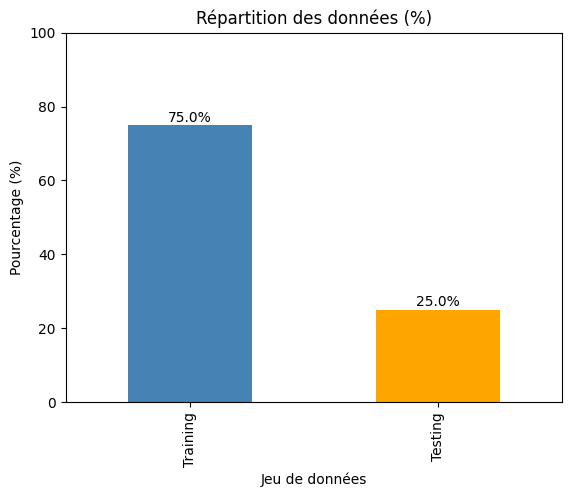

In [9]:
split_percent = pd.Series({
    "Training": len(train_data),
    "Testing": len(test_data)
})

# Conversion en pourcentages
split_percent = split_percent / split_percent.sum() * 100

ax = split_percent.plot(kind="bar", color=["steelblue", "orange"])

plt.title("Répartition des données (%)")
plt.xlabel("Jeu de données")
plt.ylabel("Pourcentage (%)")
plt.ylim(0, 100)

for i, v in enumerate(split_percent):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center")

plt.show()

### d) Graphique de la répartition des données par LABEL

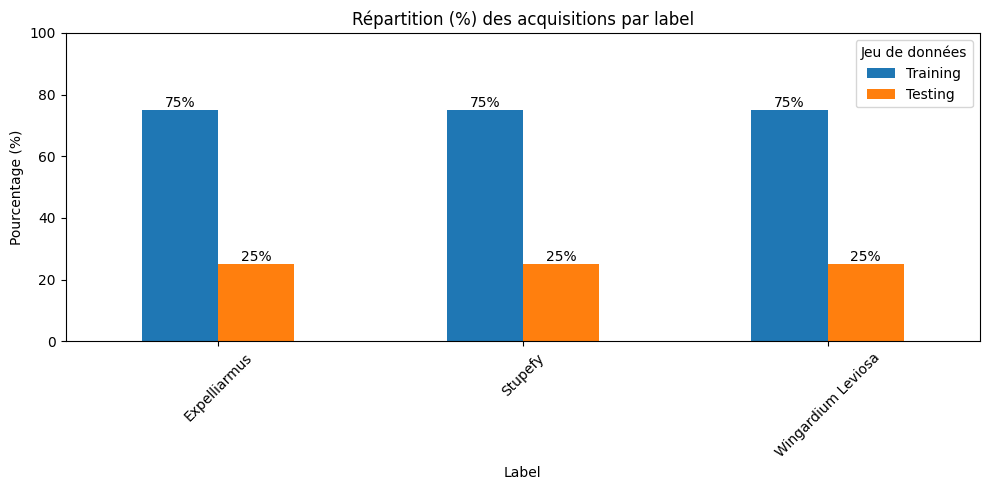

In [10]:
# Nombre d'acquisitions (source_file) par label dans chaque jeu

train_counts = (
    train_data.groupby("label")["source_file"]
    .nunique()
    .rename("Training")
)

test_counts = (
    test_data.groupby("label")["source_file"]
    .nunique()
    .rename("Testing")
)

# Fusion des résultats
label_split = pd.concat([train_counts, test_counts], axis=1).fillna(0)

# Conversion en pourcentage pour chaque label
label_split_percent = (
    label_split.div(label_split.sum(axis=1), axis=0) * 100
)

# Affichage
ax = label_split_percent.plot(kind="bar", figsize=(10, 5))

plt.title("Répartition (%) des acquisitions par label")
plt.xlabel("Label")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%")

plt.legend(title="Jeu de données")
plt.tight_layout()
plt.show()

### e) Questions

1) Afficher la taille des données d'entraînement et de test et donner les valeurs
2) Afficher par graphique la répartition des données (par label aussi?)
3) Faire le split avec un pourcentage cohérent
4) Quel serait le risque d'avoir trop de données d'entraînement? Au contraire quel serait le risque qu'il y en ait pas assez?
5) Pourquoi est-il important d'avoir des données que le modèle n'a jamais vu? Quelles sont les performances que l'on peut observer du modèle grâce à elles?
6) Pourquoi ne faut-il jamais entraîner le modèle sur les données de test ?
7) Pourquoi mélange-t-on (shuffle) généralement les données avant le découpage ?
8) Quel risque prend-on si le jeu de test n'est pas représentatif du jeu d'entraînement ?
9) Que signifie le terme "généralisation" d'un modèle ?

## 5. Analyse spectrale

Dans cette section, nous allons réaliser l'analyse spectrale d'une donnée en particulier. Nous allons d'abord observer son image temporelle pour ensuite l'analyser grâce à une transformée de Fourier rapide (FFT). Cela nous permettra ensuite de générer des caractéristiques (features) pour toutes les données que l'on pourra utiliser pour entraîner et tester le modèle.


### a) Importation des bibliothèques nécessaires

In [11]:
import numpy as np
import matplotlib.pyplot as plt

### b) Image temporelle de la donnée brute

In [12]:
#Choix d'une fonction à analyser

def choisir_acquisition(dataset, label, numero):
    """
    Sélectionne une acquisition d'un label.

    Paramètres
    ----------
    dataset : train_data ou test_data
    label : nom du label
    numero : indice de l'acquisition (0 = première, 1 = deuxième, ...)
    """

    acquisitions = (
        dataset[dataset["label"] == label]["source_file"]
        .drop_duplicates()
        .tolist()
    )

    sample_file = acquisitions[numero]
    sample = dataset[dataset["source_file"] == sample_file]

    return sample


# Exemple
sample = choisir_acquisition(train_data, "Expelliarmus", 0)

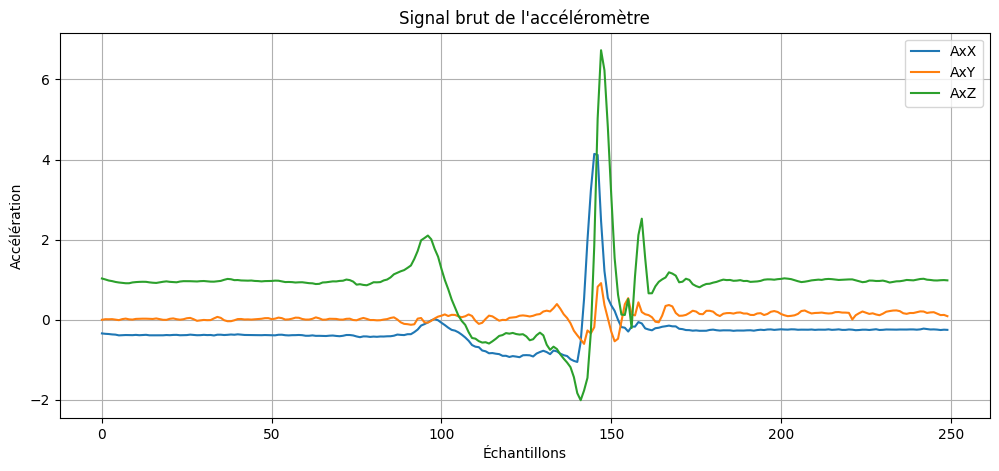

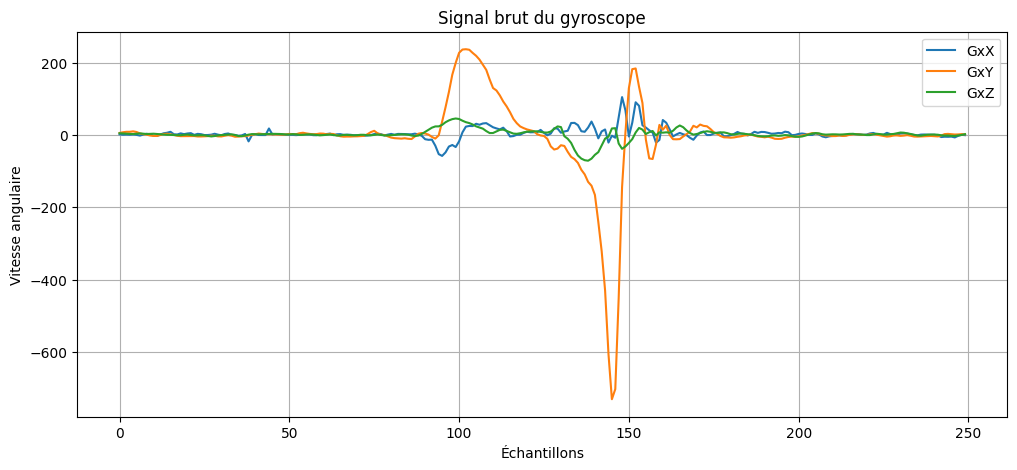

In [13]:
# Image en temporel de la donnée brute (accéléromètre)

plt.figure(figsize=(12, 5))

plt.plot(sample["AxX"], label="AxX")
plt.plot(sample["AxY"], label="AxY")
plt.plot(sample["AxZ"], label="AxZ")

plt.title("Signal brut de l'accéléromètre")
plt.xlabel("Échantillons")
plt.ylabel("Accélération")
plt.legend()
plt.grid(True)

plt.show()

# Image en temporel de la donnée brute (gyroscope)

plt.figure(figsize=(12, 5))

plt.plot(sample["GxX"], label="GxX")
plt.plot(sample["GxY"], label="GxY")
plt.plot(sample["GxZ"], label="GxZ")

plt.title("Signal brut du gyroscope")
plt.xlabel("Échantillons")
plt.ylabel("Vitesse angulaire")
plt.legend()
plt.grid(True)

plt.show()

### c) Analyse spectrale de la donnée

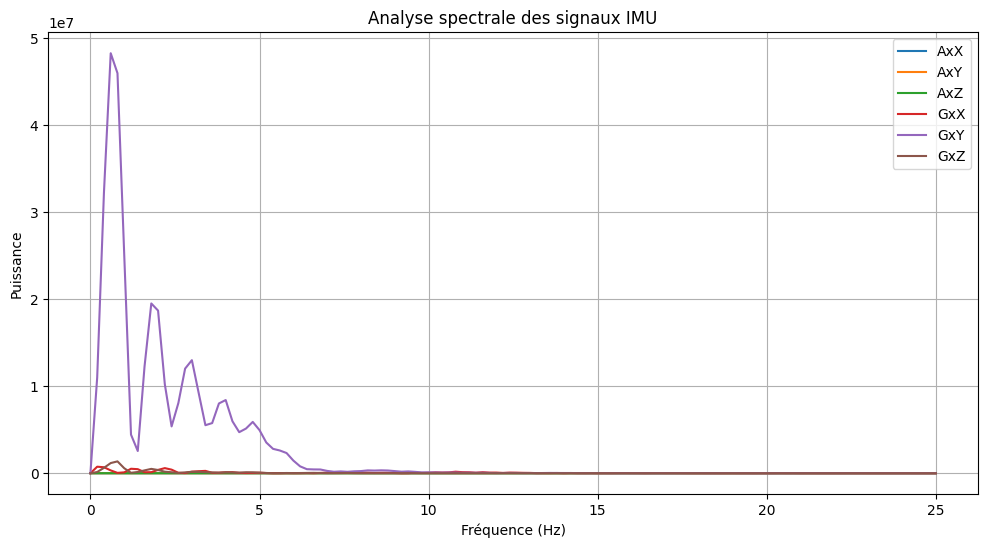

In [14]:
# Analyse spectrale (FFT)

# Fréquence d'échantillonnage
interval_ms = 20          # 20 ms si la XIAO échantillonne à 50 Hz (delay(20))
fs = 1000 / interval_ms

axes = ["AxX", "AxY", "AxZ", "GxX", "GxY", "GxZ"]

plt.figure(figsize=(12, 6))

# Application de la FFT sur chaque axe
for axis in axes:

    signal = sample[axis].values

    # Suppression de la composante continue
    signal = signal - np.mean(signal)

    fft_values = np.fft.rfft(signal)
    power = np.abs(fft_values) ** 2
    fft_freqs = np.fft.rfftfreq(len(signal), d=1/fs)

    plt.plot(fft_freqs, power, label=axis)

plt.title("Analyse spectrale des signaux IMU")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Puissance")
plt.legend()
plt.grid(True)

plt.show()

### d) Questions

1) Expliquez pourquoi il est préférable de faire une analyse fréquentielle plutot qu'une analyse temporelle dans ce cas de figure.
2) Quelle type de filtre appliqueriez vous en observant l'analyse spectrale des signaux IMU de chaque labels?
3) Determinez l'intervalle de temps pour avoir la bonne fréquence d'échantillonage correspondant à la carte Seeed Xiao NRF52840 sense.
4) Afficher l'analyse spectrale?
5) Expliquez qualitativement ce que fait la FFT sur le signal temporel et comment générer des caractéristiques par rapport au résultat obtenu.
6) Sur le sort "Expelliarmus" de numéro 0, quels sont les axes de l'IMU prédominants ? Comment vont-ils agir sur la génération des features?
7) Comment le bruit influence-t-il le spectre fréquentiel ?

## 6. Pré-traitement des données et génération de features

Ici, nous allons réaliser le pré-traitement des données avant l'entraînement du modèle:
* Nous allons d'abord réaliser un split des données d'entraînement en 2: celles qui vont servir à entraîner le modèle et celles qui vont servir à le valider
* Ensuite, nous allons réaliser l'analyse spectrale de toutes les données pour permettre la génération de caractéristiques (features) qui vont servir pour l'entraînement et le test.

### a) Importation des bibliothèques nécessaires

In [15]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler, LabelEncoder

### b) Split train/validation

In [16]:
#Fonction qui réalise le split train/validation

def split_train_validation(train_data, validation_size=0.2, random_state=42):
    """
    Sépare le jeu d'entraînement en un jeu d'entraînement et un jeu de validation.

    Le découpage est effectué par acquisition (source_file) afin qu'une
    acquisition complète appartienne soit au jeu d'entraînement, soit au
    jeu de validation. La proportion est respectée pour chaque label.

    Paramètres
    ----------
    train_data : DataFrame
        Jeu d'entraînement.
    validation_size : float
        Proportion des acquisitions à placer dans le jeu de validation.
    random_state : int
        Graine aléatoire.

    Retour
    ------
    train_final, validation_data
    """

    train_files = []
    validation_files = []

    # Découpage indépendant pour chaque label
    for label in train_data["label"].unique():

        acquisitions = (
            train_data[train_data["label"] == label]["source_file"]
            .drop_duplicates()
            .tolist()
        )

        train, validation = train_test_split(
            acquisitions,
            test_size=validation_size,
            random_state=random_state,
            shuffle=True
        )

        train_files.extend(train)
        validation_files.extend(validation)

    train_final = train_data[
        train_data["source_file"].isin(train_files)
    ].reset_index(drop=True)

    validation_data = train_data[
        train_data["source_file"].isin(validation_files)
    ].reset_index(drop=True)

    print(f"Pourcentage de validation demandé : {validation_size*100:.0f}%")
    print(f"Nombre de lignes entraînement : {len(train_final)}")
    print(f"Nombre de lignes validation : {len(validation_data)}")

    print("\nRépartition par label :")
    repartition = pd.DataFrame({
        "Training": train_final.groupby("label")["source_file"].nunique(),
        "Validation": validation_data.groupby("label")["source_file"].nunique()
    }).fillna(0).astype(int)

    repartition["Total"] = (
        repartition["Training"] + repartition["Validation"]
    )

    repartition["% Validation"] = (
        repartition["Validation"] / repartition["Total"] * 100
    ).round(1)

    display(repartition)

    return train_final, validation_data

# Deuxième découpage : Train / Validation
train_data, validation_data = split_train_validation(
    train_data,
    validation_size=0.2
)

Pourcentage de validation demandé : 20%
Nombre de lignes entraînement : 45101
Nombre de lignes validation : 11274

Répartition par label :


,Training,Validation,Total,% Validation
label,,,,
Expelliarmus,60,15,75,20.0
Stupefy,60,15,75,20.0
Wingardium Leviosa,60,15,75,20.0


### c) Génération des caractéristiques pour toutes les données

In [17]:
# Axes du capteur
axes = ["AxX", "AxY", "AxZ", "GxX", "GxY", "GxZ"]


#Fonction qui génère les caractéristiques d'une donnée par analyse spectrale
def generate_spectral_features(sample, axes=axes, n_fft=20):
    """
    Génère les caractéristiques statistiques et fréquentielles
    d'une acquisition.

    Paramètres
    ----------
    sample : DataFrame
        Acquisition à analyser.
    axes : list
        Liste des axes IMU.
    n_fft : int
        Nombre de coefficients FFT conservés.

    Retour
    ------
    dict
        Dictionnaire contenant les caractéristiques.
    """

    features = {}

    for axis in axes:

        signal = sample[axis].to_numpy(dtype=float)

        # Suppression de la composante continue
        signal = signal - np.mean(signal)

        # Caractéristiques statistiques
        features[f"{axis}_rms"] = np.sqrt(np.mean(signal**2))
        features[f"{axis}_skewness"] = skew(signal)
        features[f"{axis}_kurtosis"] = kurtosis(signal)

        # FFT
        fft_values = np.fft.rfft(signal)
        power = np.abs(fft_values) ** 2

        # Conservation des n_fft premiers coefficients
        power = power[:n_fft]

        for i, value in enumerate(power):
            features[f"{axis}_fft_{i}"] = value

    return features

In [18]:
# 2. Fonction de génération des features pour toutes les données

def construire_features(dataset):
    feature_rows = []

    for source_file, sample in dataset.groupby("source_file"):
        features = generate_spectral_features(sample, axes, n_fft=20)

        features["source_file"] = source_file
        features["label"] = sample["label"].iloc[0]

        feature_rows.append(features)

    return pd.DataFrame(feature_rows)

In [19]:
# 3. Génération des features pour les trois jeux de données
features_train = construire_features(train_data)
features_validation = construire_features(validation_data)
features_test = construire_features(test_data)

#display(features_train.head())
#display(features_validation.head())
#display(features_test.head())

X_train = features_train.drop(columns=["source_file", "label"])
y_train = features_train["label"]

X_validation = features_validation.drop(columns=["source_file", "label"])
y_validation = features_validation["label"]

X_test = features_test.drop(columns=["source_file", "label"])
y_test = features_test["label"]

### d) Codage et normalisation des features

Ici, avant l'entraînement du modèle, il est important de coder et normaliser les caractéristiques pour permettre un entraînement optimal et efficace.

In [20]:
#Codage et normalisation des features

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_validation_encoded = label_encoder.transform(y_validation)
y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_validation_scaled = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

['Expelliarmus' 'Stupefy' 'Wingardium Leviosa']


### e) Questions

1) Quelle est la différence entre les données de test et les données de validation?
2) Faire le split train/validation 
3) Quelles sont les différentes méthodes de validation et comment fonctionnent-elles?
4) Pourquoi est-il important de pré-traiter les données avant l'entraînement?
5) Faire la fonction de génération de features pour toutes les données en utilisant la fonction generate_spectral_features
6) Pourquoi est-il important de normaliser les features?
7) Pourquoi faut-il coder les features avant l'entraînement?
8) Dans quels cas utiliseriez-vous une validation croisée (Cross Validation) ?
9) Quelle est la différence entre Hold-Out, K-Fold et Leave-One-Out ?
10) Quels sont les avantages et les inconvénients du K-Fold Cross Validation ?

## 7. Classification sur données d'entraînement

Nous passons maintenant à la partie de l'entraînement du modèle avec un réseau de neurones, grâce aux données d'entraînement. 

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/reseau_neurones.png"
     alt="Réseau de neurones"
     width="600">

Cela nous permettra ensuite d'observer les performances du modèle (métriques, matrice de confusion) avec les données de validation qui serviront à régler le modèle et l'ajuster.

### a) Importation des bibliothèques nécessaires

In [21]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

### b) Création du réseau de neurones et compilation du modèle

In [22]:
#Architecture du réseau de neurones

num_features = X_train_scaled.shape[1]
num_classes = len(label_encoder.classes_)

model = Sequential([
    Dense(64, activation="relu", input_shape=(num_features,)),
    #Dropout(0.3),

    Dense(32, activation="relu"),
    #Dropout(0.3),

    Dense(num_classes, activation="softmax")
])

C:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
#Compilation du modèle

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### c) Entraînement du modèle

In [24]:
#Entraînement 

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_encoded,
    validation_data=(X_validation_scaled, y_validation_encoded),
    epochs=10,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8167 - loss: 0.5043 - val_accuracy: 1.0000 - val_loss: 0.1410
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0610 - val_accuracy: 1.0000 - val_loss: 0.0315
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0148 - val_accuracy: 1.0000 - val_loss: 0.0132
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0068 - val_accuracy: 1.0000 - val_loss: 0.0082
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 0.0062
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0032 - val_accuracy: 1.0000 - val_loss: 0.0051
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 0.0044
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0022 - val_accuracy: 1.0000 - val_loss

### d) Performances de l'entraînement

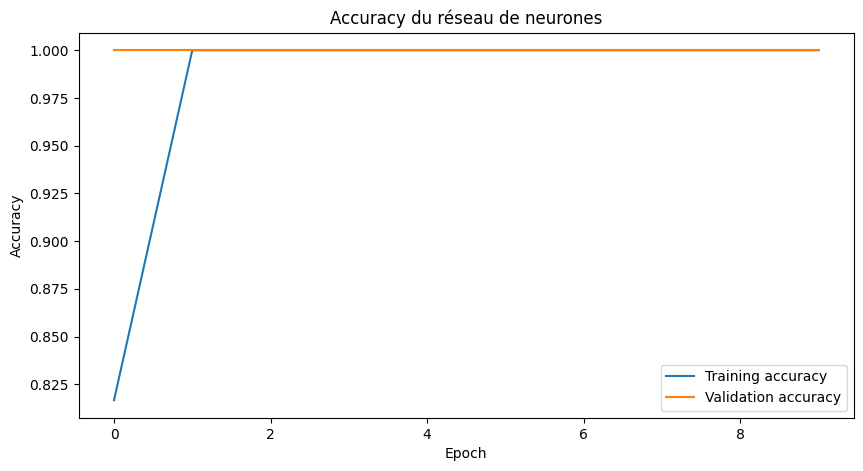

In [25]:
#Graphique de l'accuracy

plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")

plt.title("Accuracy du réseau de neurones")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

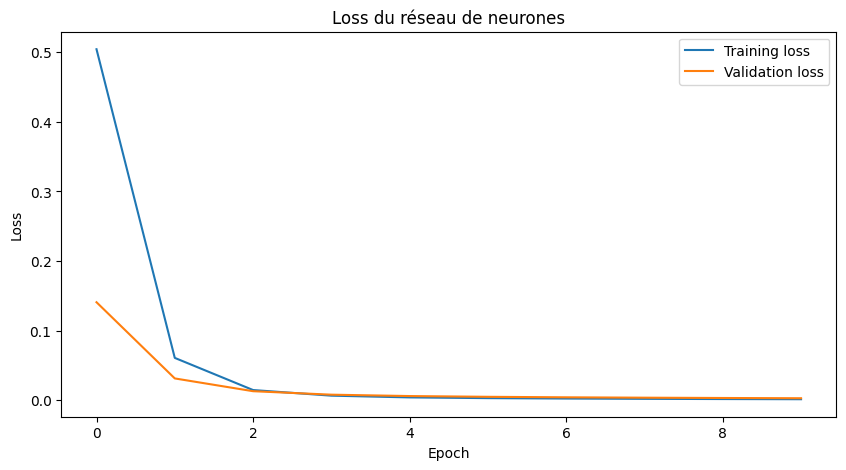

In [26]:
#Graphique de la fonction de perte du modèle

plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Loss du réseau de neurones")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [27]:
#Métriques

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd
import numpy as np

# Prédictions sur le jeu de validation
y_validation_proba = model.predict(X_validation_scaled)
y_validation_pred = np.argmax(y_validation_proba, axis=1)

# Calcul des métriques
metrics = pd.DataFrame({
    "Metric": [
        "Area under ROC Curve",
        "Weighted average Precision",
        "Weighted average Recall",
        "Weighted average F1 score"
    ],
    "Value": [
        roc_auc_score(
            y_validation_encoded,
            y_validation_proba,
            multi_class="ovr",
            average="weighted"
        ),
        precision_score(
            y_validation_encoded,
            y_validation_pred,
            average="weighted",
            zero_division=0
        ),
        recall_score(
            y_validation_encoded,
            y_validation_pred,
            average="weighted",
            zero_division=0
        ),
        f1_score(
            y_validation_encoded,
            y_validation_pred,
            average="weighted",
            zero_division=0
        )
    ]
})

metrics["Value"] = metrics["Value"].map(lambda x: f"{x:.2f}")

display(metrics)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


,Metric,Value
0,Area under ROC Curve,1.00
1,Weighted average Precision,1.00
2,Weighted average Recall,1.00
3,Weighted average F1 score,1.00


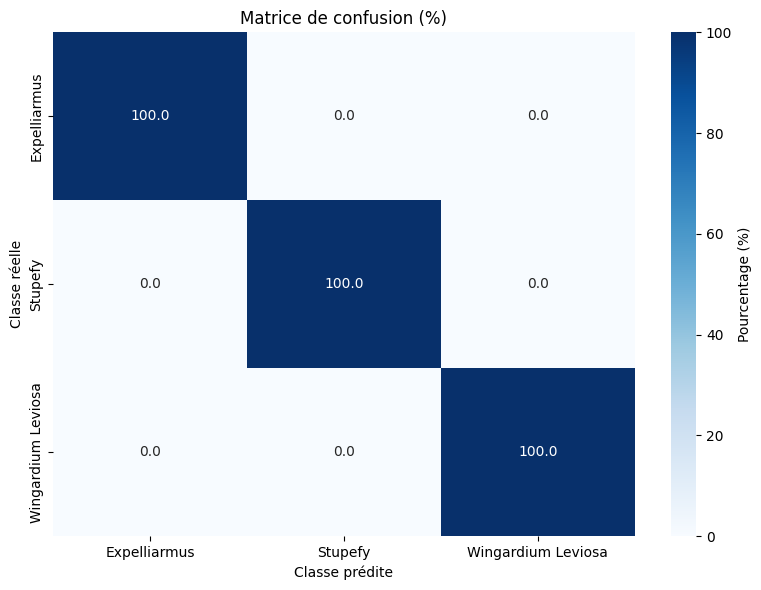

In [28]:
#Matrice de confusion

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def afficher_matrice_confusion(y_true, y_pred, labels):
    """
    Affiche une matrice de confusion normalisée en pourcentage.

    Paramètres
    ----------
    y_true : array
        Labels réels (encodés).
    y_pred : array
        Labels prédits (encodés).
    labels : list
        Liste des noms des classes.
    """

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)

    # Normalisation par ligne (classe réelle)
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm_percent,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        vmin=0,
        vmax=100,
        cbar_kws={"label": "Pourcentage (%)"}
    )

    plt.xlabel("Classe prédite")
    plt.ylabel("Classe réelle")
    plt.title("Matrice de confusion (%)")

    plt.tight_layout()
    plt.show()

afficher_matrice_confusion(
    y_validation_encoded,
    y_validation_pred,
    label_encoder.classes_
)

### e) Questions

1) Decrivez l'architecture du réseau de neurones (le nombre d'entrées/sorties, les différentes couches, les fonctions d'activation...)
2) Faites l'entraînement du modèle avec différentes époques et décrivez les différences observées au niveau des performances.
3) Afficher l'accuracy/fonction de perte de la validation en suivant l'exemple de celles de l'entraînement.
4) Expliquez la signification des métriques affichées.
5) Afficher la matrice de confusion.
6) Calculez l'accuracy du modèle grâce à la matrice de confusion avec epochs=20.
7) Comment obtenir la probabilité de détection et le ratio de faux positifs avec la matrice de confusion?
8) Quel est le rôle de la fonction d'activation ?
9) Pourquoi ajoute-t-on plusieurs couches cachées ?
10) Comment le nombre de neurones influence-t-il la capacité du modèle ?
11) Quel est le rôle du taux d'apprentissage (learning rate) ?

## 8. Test du modèle

Pour cette dernière étape avant le déploiement embarqué sur carte du modèle, nous allons tester le modèle avec les données qu'il n'a jamais vu, les données de test. Ce test permettra d'avoir les performances réelles du modèle quand on lui présente de nouvelles données qui ne lui ont pas servi pour s'entraîner.

### a) Codage et normalisation des features

Ici, avant le test du modèle, il est important de coder et normaliser les caractéristiques pour permettre un test optimal et efficace.

In [29]:
# Données de test

X_test = features_test.drop(
    columns=["source_file", "label"]
)

y_test = features_test["label"]

# Encodage des labels
y_test_encoded = label_encoder.transform(y_test)

# Normalisation des caractéristiques
X_test_scaled = scaler.transform(X_test)

### b) Prédicition du modèle sur les données de test

In [30]:
# Prédictions sur le jeu de test
y_test_proba = model.predict(X_test_scaled)
y_test_pred = np.argmax(y_test_proba, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


### c) Performance du modèle

In [31]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

# Calcul des métriques
test_metrics = pd.DataFrame({
    "Metric": [
        "Area under ROC Curve",
        "Weighted average Precision",
        "Weighted average Recall",
        "Weighted average F1 score"
    ],
    "Value": [
        roc_auc_score(
            y_test_encoded,
            y_test_proba,
            multi_class="ovr",
            average="weighted"
        ),
        precision_score(
            y_test_encoded,
            y_test_pred,
            average="weighted",
            zero_division=0
        ),
        recall_score(
            y_test_encoded,
            y_test_pred,
            average="weighted",
            zero_division=0
        ),
        f1_score(
            y_test_encoded,
            y_test_pred,
            average="weighted",
            zero_division=0
        )
    ]
})

test_metrics["Value"] = test_metrics["Value"].map(lambda x: f"{x:.2f}")

display(test_metrics.style.hide(axis="index"))

Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


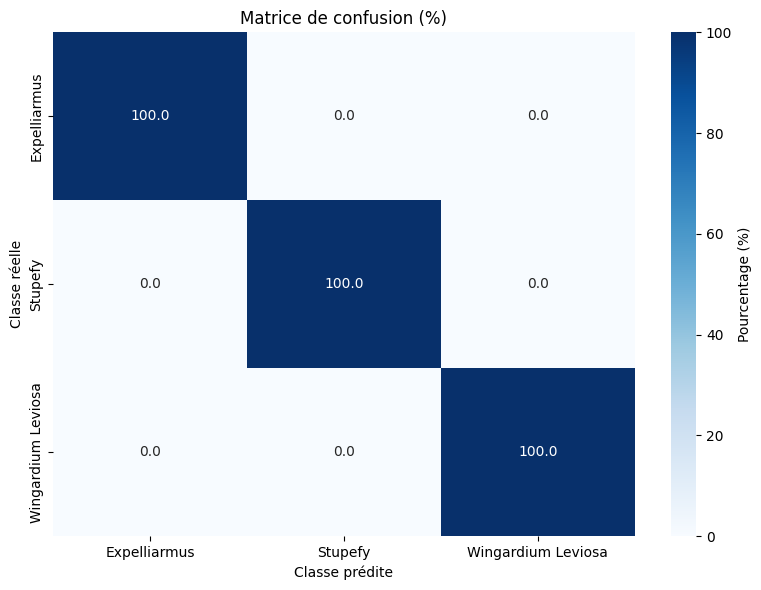

In [32]:
#Matrice de confusion

afficher_matrice_confusion(
    y_test_encoded,
    y_test_pred,
    label_encoder.classes_
)

### d) Questions

1) Quelle est la différence entre les performances de validation (avec les données de validation) et les perfomances de test (avec les données de test)?
2) Afficher la matrice de confusion et les métriques.
3) Analysez la matrice de confusion: comment améliorer la performance du modèle? Sur quels labels faut-il jouer?
4) Pourquoi l'accuracy du test est-elle plus basse que celle de la validation lors de l'entraînement?
5) Que représentent les faux positifs et les faux négatifs ?
6) Pourquoi un modèle peut-il avoir une excellente accuracy mais être peu utile ?
7) Comment détecter un surapprentissage à partir des courbes d'entraînement et de validation ?

## 9. Re-entraînement du modèle (facultatif)

Cette section est facultative, elle est à compiler si il y a de nouvelles acquisitions ou labels ajoutés au dataset de base, ou une quelquonque autre modifications

Features train : (180, 140)
Features validation : (45, 140)
Features test : (75, 140)
Labels : ['Expelliarmus' 'Stupefy' 'Wingardium Leviosa']
Epoch 1/20


C:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5611 - loss: 0.9956 - val_accuracy: 0.7111 - val_loss: 0.6170
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7778 - loss: 0.5689 - val_accuracy: 0.8667 - val_loss: 0.3606
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8889 - loss: 0.3228 - val_accuracy: 0.9778 - val_loss: 0.2356
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9111 - loss: 0.2656 - val_accuracy: 1.0000 - val_loss: 0.1474
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9778 - loss: 0.1828 - val_accuracy: 1.0000 - val_loss: 0.0936
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9667 - loss: 0.1437 - val_accuracy: 1.0000 - val_loss: 0.0590
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9833 - loss: 0.1111 - val_accuracy: 1.0000 - val_loss: 0.0385
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9889 - loss: 0.0920 - val_accuracy: 1.0000 - val_loss: 0.0262
Ep

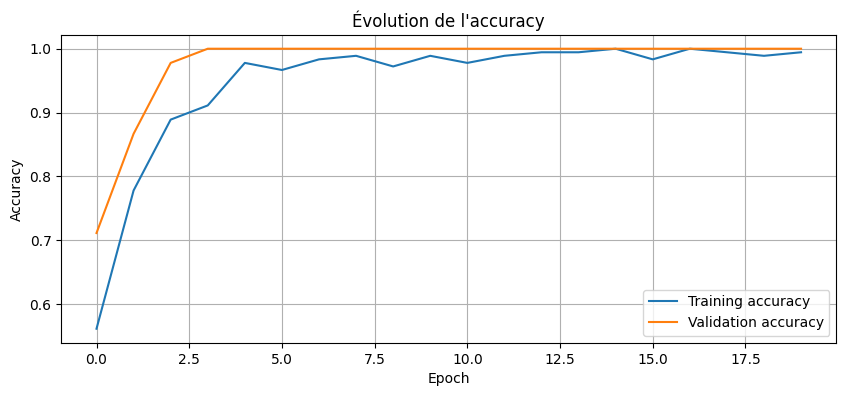

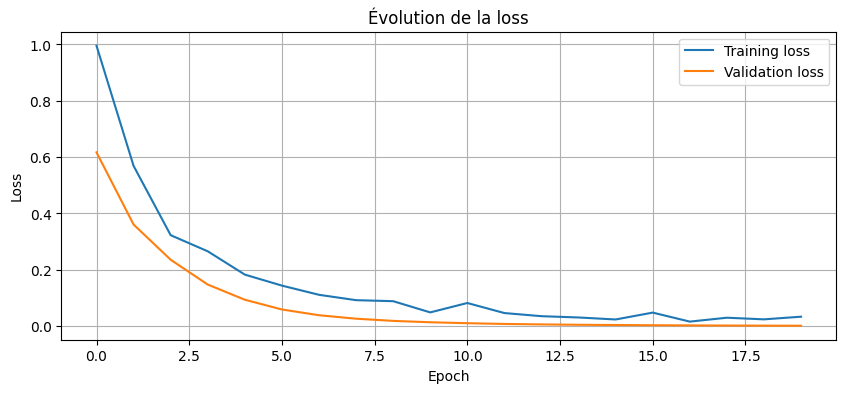

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Métriques - Validation


Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


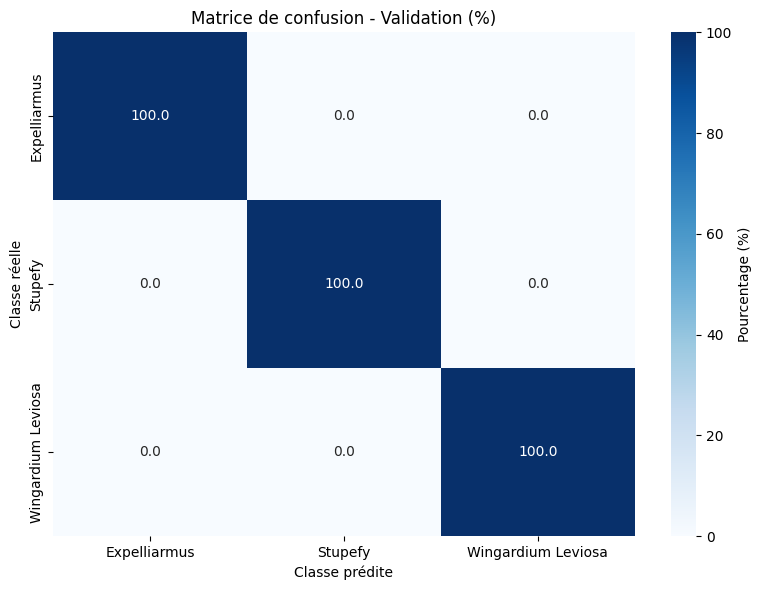

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Métriques - Test


Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


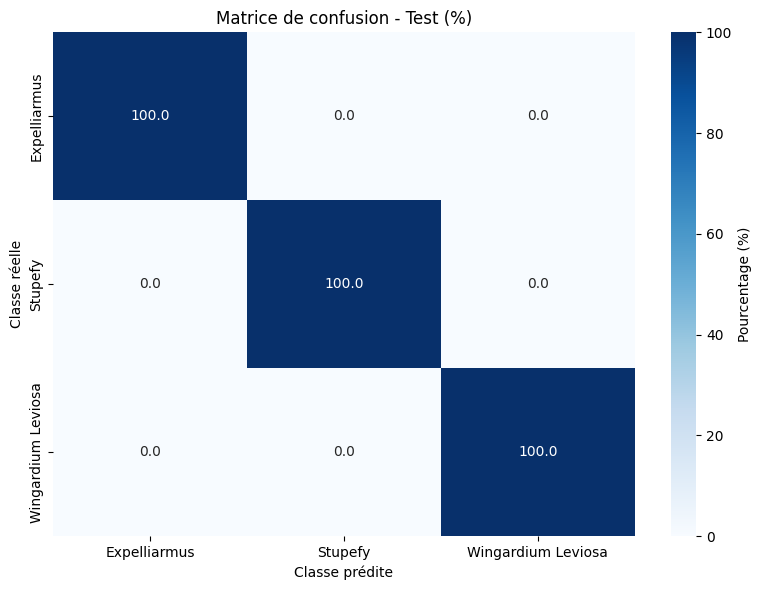

In [33]:
def reentrainer_modele(
    train_data,
    validation_data,
    test_data,
    axes=["AxX", "AxY", "AxZ", "GxX", "GxY", "GxZ"],
    n_fft=20,
    epochs=20,
    batch_size=16
):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    from scipy.stats import skew, kurtosis
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    from sklearn.metrics import (
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score,
        confusion_matrix
    )

    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping

    def generate_spectral_features(sample):
        features = {}

        for axis in axes:
            signal = sample[axis].to_numpy(dtype=float)
            signal = signal - np.mean(signal)

            features[f"{axis}_rms"] = np.sqrt(np.mean(signal ** 2))
            features[f"{axis}_skewness"] = skew(signal)
            features[f"{axis}_kurtosis"] = kurtosis(signal)

            fft_values = np.fft.rfft(signal)
            power = np.abs(fft_values) ** 2
            power = power[:n_fft]

            for i, value in enumerate(power):
                features[f"{axis}_fft_{i}"] = value

        return features

    def construire_features(dataset):
        feature_rows = []

        for source_file, sample in dataset.groupby("source_file"):
            features = generate_spectral_features(sample)

            features["source_file"] = source_file
            features["label"] = sample["label"].iloc[0]

            feature_rows.append(features)

        return pd.DataFrame(feature_rows)

    def afficher_metriques(y_true, y_pred, y_proba, titre):
        metrics = pd.DataFrame({
            "Metric": [
                "Area under ROC Curve",
                "Weighted average Precision",
                "Weighted average Recall",
                "Weighted average F1 score"
            ],
            "Value": [
                roc_auc_score(
                    y_true,
                    y_proba,
                    multi_class="ovr",
                    average="weighted"
                ),
                precision_score(y_true, y_pred, average="weighted", zero_division=0),
                recall_score(y_true, y_pred, average="weighted", zero_division=0),
                f1_score(y_true, y_pred, average="weighted", zero_division=0)
            ]
        })

        metrics["Value"] = metrics["Value"].map(lambda x: f"{x:.2f}")

        print(titre)
        display(metrics.style.hide(axis="index"))

    def afficher_matrice_confusion(y_true, y_pred, labels, titre):
        cm = confusion_matrix(y_true, y_pred)
        cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

        plt.figure(figsize=(8, 6))

        sns.heatmap(
            cm_percent,
            annot=True,
            fmt=".1f",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            vmin=0,
            vmax=100,
            cbar_kws={"label": "Pourcentage (%)"}
        )

        plt.title(titre)
        plt.xlabel("Classe prédite")
        plt.ylabel("Classe réelle")
        plt.tight_layout()
        plt.show()

    # --------------------------------------------------------
    # 1. Génération des features
    # --------------------------------------------------------

    features_train = construire_features(train_data)
    features_validation = construire_features(validation_data)
    features_test = construire_features(test_data)

    print("Features train :", features_train.shape)
    print("Features validation :", features_validation.shape)
    print("Features test :", features_test.shape)

    # --------------------------------------------------------
    # 2. Préparation des données
    # --------------------------------------------------------

    X_train = features_train.drop(columns=["source_file", "label"])
    y_train = features_train["label"]

    X_validation = features_validation.drop(columns=["source_file", "label"])
    y_validation = features_validation["label"]

    X_test = features_test.drop(columns=["source_file", "label"])
    y_test = features_test["label"]

    label_encoder = LabelEncoder()

    y_train_encoded = label_encoder.fit_transform(y_train)
    y_validation_encoded = label_encoder.transform(y_validation)
    y_test_encoded = label_encoder.transform(y_test)

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_validation_scaled = scaler.transform(X_validation)
    X_test_scaled = scaler.transform(X_test)

    print("Labels :", label_encoder.classes_)

    # --------------------------------------------------------
    # 3. Création du modèle
    # --------------------------------------------------------

    model = Sequential([
        Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(len(label_encoder.classes_), activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    )

    # --------------------------------------------------------
    # 4. Entraînement
    # --------------------------------------------------------

    history = model.fit(
        X_train_scaled,
        y_train_encoded,
        validation_data=(X_validation_scaled, y_validation_encoded),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop]
    )

    # --------------------------------------------------------
    # 5. Courbes d'entraînement
    # --------------------------------------------------------

    plt.figure(figsize=(10, 4))
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title("Évolution de l'accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title("Évolution de la loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --------------------------------------------------------
    # 6. Évaluation validation
    # --------------------------------------------------------

    y_validation_proba = model.predict(X_validation_scaled)
    y_validation_pred = np.argmax(y_validation_proba, axis=1)

    afficher_metriques(
        y_validation_encoded,
        y_validation_pred,
        y_validation_proba,
        "Métriques - Validation"
    )

    afficher_matrice_confusion(
        y_validation_encoded,
        y_validation_pred,
        label_encoder.classes_,
        "Matrice de confusion - Validation (%)"
    )

    # --------------------------------------------------------
    # 7. Évaluation test
    # --------------------------------------------------------

    y_test_proba = model.predict(X_test_scaled)
    y_test_pred = np.argmax(y_test_proba, axis=1)

    afficher_metriques(
        y_test_encoded,
        y_test_pred,
        y_test_proba,
        "Métriques - Test"
    )

    afficher_matrice_confusion(
        y_test_encoded,
        y_test_pred,
        label_encoder.classes_,
        "Matrice de confusion - Test (%)"
    )

    return {
        "model": model,
        "history": history,
        "scaler": scaler,
        "label_encoder": label_encoder,
        "features_train": features_train,
        "features_validation": features_validation,
        "features_test": features_test,
        "X_train_scaled": X_train_scaled,
        "X_validation_scaled": X_validation_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train_encoded": y_train_encoded,
        "y_validation_encoded": y_validation_encoded,
        "y_test_encoded": y_test_encoded
    }

resultats = reentrainer_modele(
    train_data,
    validation_data,
    test_data,
    n_fft=20,
    epochs=20,
    batch_size=16
)

model = resultats["model"]
scaler = resultats["scaler"]
label_encoder = resultats["label_encoder"]

## 10. Déploiement du modèle sur la carte Seeed XIAO nRF52840 Sense — inférence directe en C++

Nous allons embarquer le réseau de neurones **sans TensorFlow Lite**. Le notebook exporte simplement les poids et les biais appris dans un fichier C++ (`model_params.h`). Sur la carte, une fonction C++ calcule directement les couches denses, les activations ReLU puis le softmax.

Le déroulement sur la carte est le suivant :

1. acquisition de 100 mesures IMU à 50 Hz (fenêtre de 2 s) ;
2. calcul des mêmes 138 caractéristiques que pendant l'entraînement ;
3. normalisation avec les paramètres du `StandardScaler` ;
4. inférence C++ : couche dense 138→32, ReLU, couche dense 32→16, ReLU, couche dense 16→classes, softmax ;
5. affichage de la classe et clignotement de la LED.

Cette méthode évite totalement l'interpréteur TensorFlow Lite Micro. Elle est adaptée ici parce que l'architecture du réseau est petite et ne contient que des couches denses.


In [34]:
# ============================================================
# Export des paramètres pour une inférence C++ directe
# Génère un seul fichier : model_params.h
# Aucun fichier .tflite et aucune bibliothèque TensorFlow Lite
# ============================================================

import numpy as np
from pathlib import Path

model = resultats["model"]
scaler = resultats["scaler"]
label_encoder = resultats["label_encoder"]

# Les couches Dropout n'ont aucun rôle pendant l'inférence.
dense_layers = [layer for layer in model.layers if len(layer.get_weights()) == 2]
if len(dense_layers) != 3:
    raise ValueError(
        "Ce générateur attend exactement 3 couches Dense "
        "(entrée -> cachée 1 -> cachée 2 -> sortie)."
    )

(w1, b1), (w2, b2), (w3, b3) = [layer.get_weights() for layer in dense_layers]
labels = [str(label) for label in label_encoder.classes_]

if w1.shape[0] != len(scaler.mean_):
    raise ValueError("Le nombre de features du scaler ne correspond pas au modèle.")
if w3.shape[1] != len(labels):
    raise ValueError("Le nombre de sorties ne correspond pas au nombre de labels.")

def cpp_float(value):
    """Écriture compacte et sûre d'un float C++."""
    value = float(value)
    if not np.isfinite(value):
        raise ValueError("Un paramètre du modèle contient NaN ou inf.")
    return f"{value:.9g}f"

def write_float_array(f, name, array, per_line=8):
    values = np.asarray(array, dtype=np.float32).ravel(order="C")
    f.write(f"const float {name}[{len(values)}] = {{\n")
    for start in range(0, len(values), per_line):
        row = ", ".join(cpp_float(x) for x in values[start:start + per_line])
        f.write("  " + row)
        if start + per_line < len(values):
            f.write(",")
        f.write("\n")
    f.write("};\n\n")

header_path = Path("model_params.h")
with header_path.open("w", encoding="utf-8", newline="\n") as f:
    f.write("#ifndef MODEL_PARAMS_H\n#define MODEL_PARAMS_H\n\n")
    f.write("#include <Arduino.h>\n\n")
    f.write(f"constexpr int N_FEATURES = {w1.shape[0]};\n")
    f.write(f"constexpr int N_HIDDEN_1 = {w1.shape[1]};\n")
    f.write(f"constexpr int N_HIDDEN_2 = {w2.shape[1]};\n")
    f.write(f"constexpr int N_CLASSES = {w3.shape[1]};\n\n")

    write_float_array(f, "SCALER_MEAN", scaler.mean_)
    write_float_array(f, "SCALER_SCALE", scaler.scale_)
    # Keras stocke chaque matrice sous la forme [entrée, sortie].
    # L'aplatissement C conserve exactement cet ordre.
    write_float_array(f, "W1", w1)
    write_float_array(f, "B1", b1)
    write_float_array(f, "W2", w2)
    write_float_array(f, "B2", b2)
    write_float_array(f, "W3", w3)
    write_float_array(f, "B3", b3)

    escaped_labels = [label.replace("\\", "\\\\").replace('"', '\\"') for label in labels]
    f.write("const char* const LABELS[N_CLASSES] = {\n  ")
    f.write(", ".join(f'"{label}"' for label in escaped_labels))
    f.write("\n};\n\n#endif\n")

parameter_count = sum(w.size + b.size for w, b in [
    (w1, b1), (w2, b2), (w3, b3)
])
print(f"Fichier généré : {header_path.resolve()}")
print(f"Architecture : {w1.shape[0]} -> {w1.shape[1]} -> {w2.shape[1]} -> {w3.shape[1]}")
print(f"Paramètres exportés : {parameter_count}")
print(f"Mémoire approximative des poids en float32 : {4 * parameter_count / 1024:.1f} Kio")


Fichier généré : \\netapp2\bassant-koum\Stage IA\Jupyter notebook\model_params.h
Architecture : 138 -> 32 -> 16 -> 3
Paramètres exportés : 5027
Mémoire approximative des poids en float32 : 19.6 Kio


In [35]:
# PySerial est uniquement nécessaire pour lire le moniteur série dans Jupyter.
%pip install pyserial


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
# ============================================================
# Génération, compilation et téléversement du sketch Arduino
# Inference directe en C++ : Dense + ReLU + Softmax
# ============================================================

import os
import time
import shutil
import subprocess
import serial

# À adapter à votre ordinateur
PORT = "COM10"
BAUDRATE = 115200
ARDUINO_CLI = r"U:\Stage IA\arduino-cli.exe"
FQBN = "Seeeduino:nrf52:xiaonRF52840Sense"

SKETCH_NAME = "deploiement_xiao_cpp"
SKETCH_DIR = os.path.join(os.getcwd(), SKETCH_NAME)
os.makedirs(SKETCH_DIR, exist_ok=True)
ino_path = os.path.join(SKETCH_DIR, SKETCH_NAME + ".ino")

arduino_code = r"""
#include <Arduino.h>
#include <Wire.h>
#include <LSM6DS3.h>
#include <math.h>
#include "model_params.h"

LSM6DS3 imu(I2C_MODE, 0x6A);

constexpr int SAMPLE_RATE_HZ = 50;
constexpr int N_SAMPLES = 100;
constexpr int N_AXES = 6;
constexpr int N_FFT = 20;
constexpr uint32_t SERIAL_BAUDRATE = 115200;
constexpr uint32_t SAMPLE_PERIOD_US = 1000000UL / SAMPLE_RATE_HZ;
constexpr float EPSILON = 1.0e-12f;

float samples[N_SAMPLES][N_AXES];
float features[N_FEATURES];
float hidden1[N_HIDDEN_1];
float hidden2[N_HIDDEN_2];
float probabilities[N_CLASSES];

static_assert(N_FEATURES == N_AXES * (3 + N_FFT),
              "N_FEATURES ne correspond pas au calcul des features");

void acquireWindow();
void computeFeatures();
void normalizeFeatures();
void predictDirectCpp(const float* input, float* output);
void blinkLed(int count);

void setup() {
  Serial.begin(SERIAL_BAUDRATE);
  // Ne pas bloquer la carte si elle fonctionne ensuite sans câble USB.
  const uint32_t serialStart = millis();
  while (!Serial && millis() - serialStart < 3000) {}

  pinMode(LED_BUILTIN, OUTPUT);
  digitalWrite(LED_BUILTIN, HIGH); // LED éteinte (logique inversée)

  if (imu.begin() != 0) {
    Serial.println("Erreur : IMU non detectee");
    while (true) delay(1000);
  }
  Serial.println("XIAO prete - inference C++ directe.");
}

void loop() {
  Serial.println("Preparez le geste...");
  delay(1000);

  digitalWrite(LED_BUILTIN, LOW);  // LED allumée pendant l'acquisition
  acquireWindow();
  digitalWrite(LED_BUILTIN, HIGH);

  computeFeatures();
  normalizeFeatures();
  predictDirectCpp(features, probabilities);

  int best = 0;
  for (int i = 1; i < N_CLASSES; ++i) {
    if (probabilities[i] > probabilities[best]) best = i;
  }

  Serial.print("Sort reconnu : ");
  Serial.print(LABELS[best]);
  Serial.print(" | Score : ");
  Serial.println(probabilities[best], 4);
  blinkLed(best + 1);
  delay(2000);
}

void acquireWindow() {
  uint32_t nextSample = micros();
  for (int i = 0; i < N_SAMPLES; ++i) {
    samples[i][0] = imu.readFloatAccelX();
    samples[i][1] = imu.readFloatAccelY();
    samples[i][2] = imu.readFloatAccelZ();
    samples[i][3] = imu.readFloatGyroX();
    samples[i][4] = imu.readFloatGyroY();
    samples[i][5] = imu.readFloatGyroZ();

    nextSample += SAMPLE_PERIOD_US;
    while ((int32_t)(micros() - nextSample) < 0) {}
  }
}

void computeFeatures() {
  int featureIndex = 0;
  for (int axis = 0; axis < N_AXES; ++axis) {
    float mean = 0.0f;
    for (int n = 0; n < N_SAMPLES; ++n) mean += samples[n][axis];
    mean /= N_SAMPLES;

    float m2 = 0.0f, m3 = 0.0f, m4 = 0.0f;
    for (int n = 0; n < N_SAMPLES; ++n) {
      const float x = samples[n][axis] - mean;
      const float x2 = x * x;
      m2 += x2;
      m3 += x2 * x;
      m4 += x2 * x2;
    }
    m2 /= N_SAMPLES;
    m3 /= N_SAMPLES;
    m4 /= N_SAMPLES;

    // Même convention que scipy.stats.skew/kurtosis avec bias=True.
    features[featureIndex++] = sqrtf(m2);
    features[featureIndex++] = (m2 > EPSILON) ? m3 / powf(m2, 1.5f) : 0.0f;
    features[featureIndex++] = (m2 > EPSILON) ? m4 / (m2 * m2) - 3.0f : 0.0f;

    // DFT directe des 20 premiers bins, équivalente aux valeurs utiles de rfft.
    for (int k = 0; k < N_FFT; ++k) {
      float re = 0.0f, im = 0.0f;
      for (int n = 0; n < N_SAMPLES; ++n) {
        const float x = samples[n][axis] - mean;
        const float angle = -2.0f * PI * k * n / N_SAMPLES;
        re += x * cosf(angle);
        im += x * sinf(angle);
      }
      features[featureIndex++] = re * re + im * im;
    }
  }
}

void normalizeFeatures() {
  for (int i = 0; i < N_FEATURES; ++i) {
    features[i] = (features[i] - SCALER_MEAN[i]) / SCALER_SCALE[i];
  }
}

void denseRelu(const float* input, int inputSize,
               const float* weights, const float* bias,
               float* output, int outputSize) {
  for (int j = 0; j < outputSize; ++j) {
    float sum = bias[j];
    for (int i = 0; i < inputSize; ++i) {
      // Matrices Keras exportées en ordre [entrée, sortie].
      sum += input[i] * weights[i * outputSize + j];
    }
    output[j] = (sum > 0.0f) ? sum : 0.0f;
  }
}

void denseLinear(const float* input, int inputSize,
                 const float* weights, const float* bias,
                 float* output, int outputSize) {
  for (int j = 0; j < outputSize; ++j) {
    float sum = bias[j];
    for (int i = 0; i < inputSize; ++i) {
      sum += input[i] * weights[i * outputSize + j];
    }
    output[j] = sum;
  }
}

void softmax(float* values, int size) {
  float maximum = values[0];
  for (int i = 1; i < size; ++i) maximum = max(maximum, values[i]);

  float total = 0.0f;
  for (int i = 0; i < size; ++i) {
    values[i] = expf(values[i] - maximum); // stabilisation numérique
    total += values[i];
  }
  if (total <= 0.0f) return;
  for (int i = 0; i < size; ++i) values[i] /= total;
}

void predictDirectCpp(const float* input, float* output) {
  denseRelu(input, N_FEATURES, W1, B1, hidden1, N_HIDDEN_1);
  denseRelu(hidden1, N_HIDDEN_1, W2, B2, hidden2, N_HIDDEN_2);
  denseLinear(hidden2, N_HIDDEN_2, W3, B3, output, N_CLASSES);
  softmax(output, N_CLASSES);
}

void blinkLed(int count) {
  for (int i = 0; i < count; ++i) {
    digitalWrite(LED_BUILTIN, LOW);
    delay(250);
    digitalWrite(LED_BUILTIN, HIGH);
    delay(250);
  }
}
"""

if not os.path.exists("model_params.h"):
    raise FileNotFoundError("Exécutez d'abord la cellule qui génère model_params.h")

shutil.copy2("model_params.h", os.path.join(SKETCH_DIR, "model_params.h"))
with open(ino_path, "w", encoding="utf-8", newline="\n") as f:
    f.write(arduino_code)

print("Sketch généré :", ino_path)
print("Compilation...")
compile_result = subprocess.run(
    [ARDUINO_CLI, "compile", "--fqbn", FQBN, SKETCH_DIR],
    capture_output=True, text=True
)
print(compile_result.stdout)
print(compile_result.stderr)
if compile_result.returncode != 0:
    raise RuntimeError("Échec de la compilation Arduino")

print("Téléversement...")
upload_result = subprocess.run(
    [ARDUINO_CLI, "upload", "-p", PORT, "--fqbn", FQBN, SKETCH_DIR],
    capture_output=True, text=True
)
print(upload_result.stdout)
print(upload_result.stderr)
if upload_result.returncode != 0:
    raise RuntimeError("Échec du téléversement Arduino")

print("Téléversement terminé. Ouverture du moniteur série...")
ser = None
try:
    ser = serial.Serial(PORT, BAUDRATE, timeout=1)
    time.sleep(2)
    while True:
        line = ser.readline().decode("utf-8", errors="ignore").strip()
        if line:
            print(line)
except KeyboardInterrupt:
    print("Moniteur série arrêté.")
finally:
    if ser is not None and ser.is_open:
        ser.close()


Sketch généré : U:\Stage IA\Jupyter notebook\deploiement_xiao_cpp\deploiement_xiao_cpp.ino
Compilation...

Unable to get Documents Folder: Le fichier spÃ©cifiÃ© est introuvable.
Error during build: Platform 'Seeeduino:nrf52' not found: platform not installed
Platform Seeeduino:nrf52 is not found in any known index
Maybe you need to add a 3rd party URL?



RuntimeError: Échec de la compilation Arduino

### b) Questions

1) Expliquez pourquoi on parle de modèle « embarqué ».
2) Quel est le rôle de `model_params.h` dans cette version sans TensorFlow Lite ?
3) Décrivez le calcul effectué par une couche dense et par l'activation ReLU.
4) Pourquoi le softmax est-il stabilisé en soustrayant le plus grand logit ?
5) Pourquoi les features et leur ordre doivent-ils être strictement identiques entre Python et C++ ?
6) Pourquoi faut-il réutiliser exactement la moyenne et l'écart-type du `StandardScaler` entraîné ?
7) Quels sont les avantages et les limites d'une inférence C++ écrite directement par rapport à un interpréteur générique ?
8) Quelles contraintes de mémoire et de temps de calcul rencontre-t-on sur la XIAO nRF52840 Sense ?
9) Pourquoi la cadence réelle d'acquisition doit-elle rester proche de 50 Hz ?
10) Comment vérifieriez-vous numériquement que l'inférence C++ produit la même classe que `model.predict()` ?
